In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.load_dataset?

Signature: sns.load_dataset(name, cache=True, data_home=None, **kws)
Docstring:
Load an example dataset from the online repository (requires internet).

This function provides quick access to a small number of example datasets
that are useful for documenting seaborn or generating reproducible examples
for bug reports. It is not necessary for normal usage.

Note that some of the datasets have a small amount of preprocessing applied
to define a proper ordering for categorical variables.

Use :func:`get_dataset_names` to see a list of available datasets.

Parameters
----------
name : str
    Name of the dataset (``{name}.csv`` on
    https://github.com/mwaskom/seaborn-data).
cache : boolean, optional
    If True, try to load from the local cache first, and save to the cache
    if a download is required.
data_home : string, optional
    The directory in which to cache data; see :func:`get_data_home`.
kws : keys and values, optional
    Additional keyword arguments are passed to passed thr

In [3]:
df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


# Overview

In [4]:
df.describe(include = 'all')

,total_bill,tip,sex,smoker,day,time,size
count,244.000000,244.000000,244,244,244,244,244.000000
unique,NaN,NaN,2,2,4,2,NaN
top,NaN,NaN,Male,No,Sat,Dinner,NaN
freq,NaN,NaN,157,151,87,176,NaN
mean,19.785943,2.998279,NaN,NaN,NaN,NaN,2.569672
std,8.902412,1.383638,NaN,NaN,NaN,NaN,0.951100
min,3.070000,1.000000,NaN,NaN,NaN,NaN,1.000000
25%,13.347500,2.000000,NaN,NaN,NaN,NaN,2.000000
50%,17.795000,2.900000,NaN,NaN,NaN,NaN,2.000000
75%,24.127500,3.562500,NaN,NaN,NaN,NaN,3.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


## Insights : 
##### 1. May be, Tip column has outliers
##### 2. Most people comes for Dinner

## Creating BAR chart for each categorical features

In [6]:
plt?

Type:        module
String form: <module 'matplotlib.pyplot' from 'd:\\python_proj\\venv\\Lib\\site-packages\\matplotlib\\pyplot.py'>
File:        d:\python_proj\venv\lib\site-packages\matplotlib\pyplot.py
Docstring:  
`matplotlib.pyplot` is a state-based interface to matplotlib. It provides
an implicit,  MATLAB-like, way of plotting.  It also opens figures on your
screen, and acts as the figure GUI manager.

pyplot is mainly intended for interactive plots and simple cases of
programmatic plot generation::

    import numpy as np
    import matplotlib.pyplot as plt

    x = np.arange(0, 5, 0.1)
    y = np.sin(x)
    plt.plot(x, y)
    plt.show()

The explicit object-oriented API is recommended for complex plots, though
pyplot is still usually used to create the figure and often the Axes in the
figure. See `.pyplot.figure`, `.pyplot.subplots`, and
`.pyplot.subplot_mosaic` to create figures, and
:doc:`Axes API </api/axes_api>` for the plotting methods on an Axes::

    import numpy as np

In [7]:
y = pd.Series(df.groupby('sex')['sex'].count())
y

sex
Male      157
Female     87
Name: sex, dtype: int64

In [8]:
cat = ['sex','smoker','day','time']
col = iter(cat)
for i in range(4):
    print(next(col))
    

sex
smoker
day
time


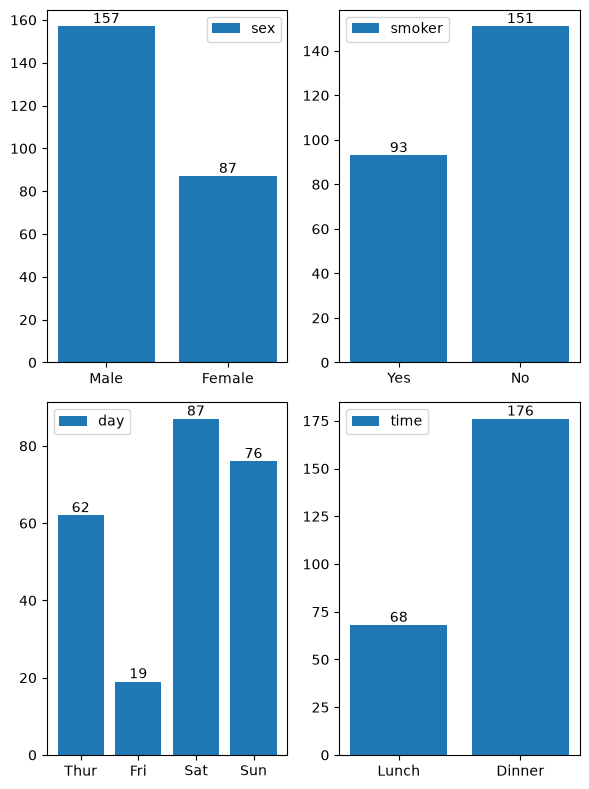

In [9]:
fig,ax = plt.subplots(2,2, figsize=(6,8))
def bar(col):
    x = pd.Series(df.groupby(col_n)[col_n].count())
    return x
cat = ['sex','smoker','day','time']
col = iter(cat)
for i in range(2):
    for j in range(2):
        col_n = next(col)
        y = bar(col_n)
        bars = ax[i][j].bar(y.index, height = y, label = col_n)
        ax[i][j].bar_label(bars, label_type = "edge")
        ax[i][j].legend()
plt.tight_layout()
#plt.legend()
#plt.show()


[Text(0, 0, '1'), Text(0, 0, '2'), Text(0, 0, '3'), Text(0, 0, '4')]

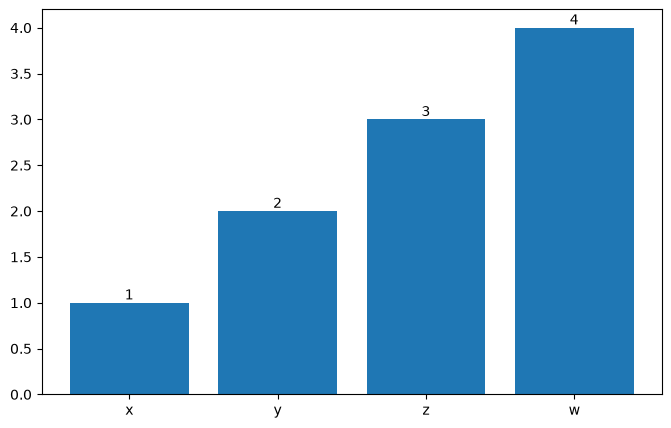

In [10]:
x = [1,2,3,4]
y = ['x','y','z','w']
fig, ax = plt.subplots(1,1, figsize=(8,5))
bars = ax.bar(y, x)
ax.bar_label(bars, label_type="edge")

# Distributin of quantitative data

In [11]:
df.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='str')

In [12]:
min(df['total_bill'])

3.07

(array([41., 79., 66., 27., 19.,  5.,  4.,  1.,  1.,  1.]),
 array([ 1. ,  1.9,  2.8,  3.7,  4.6,  5.5,  6.4,  7.3,  8.2,  9.1, 10. ]),
 <BarContainer object of 10 artists>)

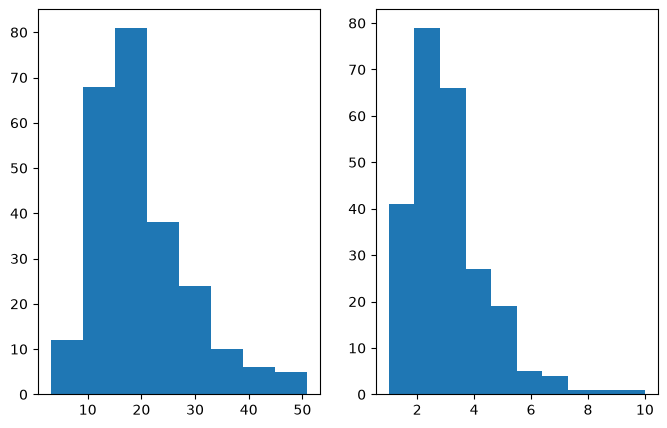

In [13]:
x = 4 + np.random.normal(0,1.5,200)
#print(x)
fig, ax = plt.subplots(1,2,figsize = (8,5))
ax[0].hist(df['total_bill'], bins=8)
#ax[0].set(xlim = (0,50), xticks=np.linspace(1, 50,num = 5, retstep = True))
ax[1].hist(df['tip'])

In [14]:
# HeatMap of bill, tip and size
# Distribution Chart For total bill and tips

## Insights
##### Distribution is right skewed

# Correlation Coefficient of quantitaive variable

In [15]:
x = [[1,2,3,4],
     [3,8,5,6],
     [4,3,2,1]]
y = np.corrcoef(x)
y

array([[ 1.       ,  0.3721042, -1.       ],
       [ 0.3721042,  1.       , -0.3721042],
       [-1.       , -0.3721042,  1.       ]])

In [16]:
df1 = pd.DataFrame(y, columns= list('xyz'))
df1

,x,y,z
0,1.000000,0.372104,-1.000000
1,0.372104,1.000000,-0.372104
2,-1.000000,-0.372104,1.000000


<Axes: >

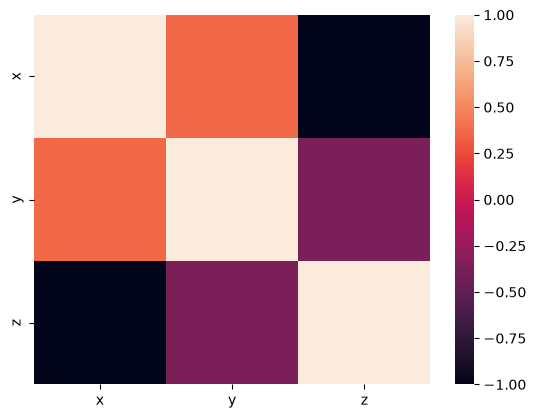

In [17]:
sns.heatmap(df1,yticklabels=df1.columns)

In [18]:
df.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='str')

In [19]:
df[['total_bill','tip','size']].head().T

,0,1,2,3,4
total_bill,16.99,10.34,21.01,23.68,24.59
tip,1.01,1.66,3.50,3.31,3.61
size,2.00,3.00,3.00,2.00,4.00


In [20]:
var = ['total_bill','tip','size']
df2 = np.corrcoef(df[var].T)
df2

array([[1.        , 0.67573411, 0.59831513],
       [0.67573411, 1.        , 0.48929878],
       [0.59831513, 0.48929878, 1.        ]])

<Axes: >

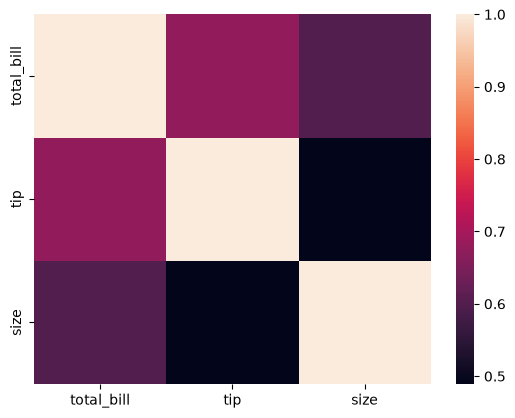

In [21]:
sns.heatmap(df2,xticklabels=var, yticklabels=var)

## Insights
##### Tip vs Size are less correlated
##### total_bill vs Tip are high correlated
##### total_bill vs size are also high

# comparing each catagory with each other for features time, day, smoker using box plot

{'whiskers': [<matplotlib.lines.Line2D at 0x196dff5fd10>,
 'caps': [<matplotlib.lines.Line2D at 0x196dff68b60>,
 'boxes': [<matplotlib.patches.PathPatch at 0x196dff689b0>,
 'medians': [<matplotlib.lines.Line2D at 0x196dff69040>,
 'fliers': [<matplotlib.lines.Line2D at 0x196dff694f0>,
 'means': [<matplotlib.lines.Line2D at 0x196dff69280>,
  <matplotlib.lines.Line2D at 0x196dff6baa0>]}

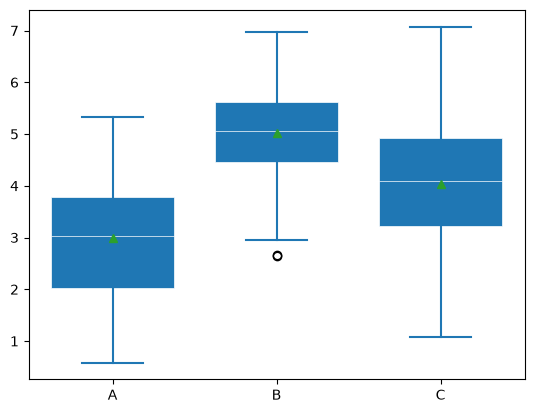

In [43]:
D = np.random.normal((3, 5, 4), (1.25, 1.00, 1.25), (100, 3))
D
fig, ax = plt.subplots()
ax.boxplot(D, positions=[2, 4, 6], widths=1.5, patch_artist=True,
                showmeans=True, tick_labels=['A','B','C'], 
                medianprops={"color": "white", "linewidth": 0.5},
                boxprops={"facecolor": "C0", "edgecolor": "white",
                          "linewidth": 0.5},
                whiskerprops={"color": "C0", "linewidth": 1.5},
                capprops={"color": "C0", "linewidth": 1.5})

In [34]:
df[df["sex"] == "Male"]

,total_bill,tip,sex,smoker,day,time,size
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
5,25.29,4.71,Male,No,Sun,Dinner,4
6,8.77,2.00,Male,No,Sun,Dinner,2
...,...,...,...,...,...,...,...
236,12.60,1.00,Male,Yes,Sat,Dinner,2
237,32.83,1.17,Male,Yes,Sat,Dinner,2
239,29.03,5.92,Male,No,Sat,Dinner,3
241,22.67,2.00,Male,Yes,Sat,Dinner,2


{'whiskers': [<matplotlib.lines.Line2D at 0x196e0e42cc0>,
 'caps': [<matplotlib.lines.Line2D at 0x196e0e74260>,
 'boxes': [<matplotlib.patches.PathPatch at 0x196e0e41520>,
 'medians': [<matplotlib.lines.Line2D at 0x196e0e74740>,
 'fliers': [<matplotlib.lines.Line2D at 0x196e0e74980>,
 'means': []}

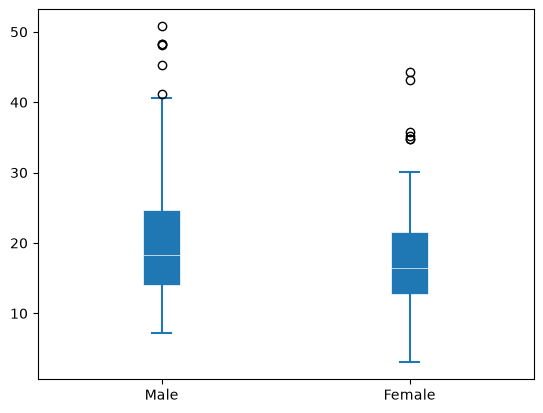

In [ ]:
#x = np.random.randint(1, 50, size = 200)
fig, ax = plt.subplots()
ax.boxplot([df[df["sex"] == "Male"]["total_bill"],
                df[df["sex"] == "Female"]["total_bill"]],
                patch_artist = True, tick_labels = ["Male", "Female"],
                medianprops={"color": "white", "linewidth": 0.5},
                boxprops={"facecolor": "C0", "edgecolor": "white","linewidth": 0.5},
                whiskerprops={"color": "C0", "linewidth": 1.5},
                capprops={"color": "C0", "linewidth": 1.5}
                )

In [ ]:
cat = ["smoker", "day","time","sex"]
catt = iter(cat)
for i in range(4):
    print(next(catt))

smoker
day
time
sex


In [ ]:
fig,ax = plt.subplots()

ax.boxplot()

AttributeError: 'list' object has no attribute 'array'

['No' 'Yes']
['Sun' 'Sat' 'Thur' 'Fri']
['Dinner' 'Lunch']
['Female' 'Male']


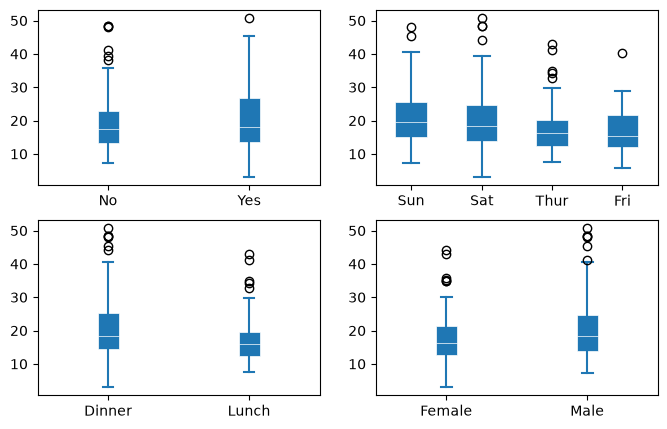

In [93]:
fig, ax = plt.subplots(2,2,figsize= (8,5))
cat = ["smoker", "day","time","sex"]
catt = iter(cat)
def uni(x,y=""):
    y = np.array(df[x].unique())
    array = []
    for z in y: 
        array.append(np.array(df[df[x] == z]["total_bill"]))
    return array,y
for i in range(2):
    for j in range(2):
        col = next(catt)
        arrayy,y = uni(col,y="")
        #np.asarray(arrayy)
        #print(f"{col}: {arrayy}")
        print(y)
        ax[i][j].boxplot(arrayy, patch_artist = True, tick_labels = y,
                    medianprops={"color": "white", "linewidth": 0.5},
                    boxprops={"facecolor": "C0", "edgecolor": "white","linewidth": 0.5},
                    whiskerprops={"color": "C0", "linewidth": 1.5},
                    capprops={"color": "C0", "linewidth": 1.5}
                    )

    

## Insight
##### Box plot comparing each catagory in the features
##### showing outliers, right skewed distribution
##### outlier is at every catagory
##### smokers has less outliers